# Layout-Aware Embedding Demonstration using LayoutXLM (Multilingual)

`microsoft/layoutxlm-base` is a **layout-aware embedding model for OCR output**. It takes
the words Tesseract extracted plus their bounding boxes and converts them into rich
768-dimensional vectors that encode both *what each word says* and *where it sits on the
page* -- in **53 languages natively** via SentencePiece / XLM-RoBERTa tokenisation.

This notebook demonstrates exactly what the model produces:

1. **Load image** -- supports JPG, PNG, PDF (first page).
2. **Preprocess + OCR** -- Tesseract returns each word with its bounding box.
3. **Tokenisation** -- LayoutXLM's SentencePiece tokeniser maps OCR words to subword
   token IDs and aligns bounding boxes to each subword.
4. **Tokenisation table** -- shows every OCR word, its subword tokens, token IDs, and
   normalised 0-1000 bbox coordinates.
5. **Spatial layout visualisation** -- draws the OCR word bboxes on the document image.
6. **Batch token statistics** -- token count, subword split ratio across the full dataset.

### What this model is (and is not)

| | |
|---|---|
| YES | An embedding model -- converts OCR words + page positions into number vectors |
| YES | Multilingual -- 53 languages, single checkpoint, SentencePiece vocabulary |
| NO | A field extractor -- it cannot find a patient name or date on its own |
| NO | A QA model -- it cannot answer questions |

> To do field extraction with this model you would fine-tune a token-classification head
> on labelled documents (e.g. XFUND). See `impira/layoutlm-document-qa` or
> `naver-clova-ix/donut-base-finetuned-docvqa` in this repo for ready-to-use extractors.

### Models and tools

| Component | Value |
|---|---|
| OCR engine | Tesseract (`pytesseract`) |
| Layout model | `microsoft/layoutxlm-base` |
| Model role | **Embedding model** -- text + layout into token vectors |
| Tokeniser | `LayoutXLMTokenizerFast` (SentencePiece, 53 languages) |
| Full model | `LayoutLMv2Model` -- requires detectron2, not loaded here |
| Tokeniser size | ~1 MB download |
| License | **CC BY-NC-SA 4.0 -- non-commercial only** |

## Architecture Diagram

GitHub only renders Mermaid diagrams in `.md` files, Issues, Discussions, and PRs -- not
inside Jupyter notebook markdown cells. See the rendered diagram and full documentation in
[README.md](./README.md#extraction-pipeline).

## Step 0 -- Environment Setup

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
print("Project root:", PROJECT_ROOT)

Project root: /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing


## Configuration and Image Discovery

| Variable | Meaning |
|---|---|
| `IMAGE_FOLDER` | Folder scanned recursively for input images |
| `INSPECT_INDEX` | Index into the sorted file list for single-image inspection |
| `EXTENSIONS` | File suffixes accepted (case-insensitive) |

In [2]:
# -- Configuration -----------------------------------------------------------
IMAGE_FOLDER  = Path.cwd().parent.parent / "test_data" / "sick_notes"
INSPECT_INDEX = 0
EXTENSIONS    = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".pdf"}
# ----------------------------------------------------------------------------

if not IMAGE_FOLDER.exists():
    raise FileNotFoundError(f"Folder not found: {IMAGE_FOLDER}")

image_paths = sorted(
    p for p in IMAGE_FOLDER.rglob("*")
    if p.is_file() and p.suffix.lower() in EXTENSIONS
)

if not image_paths:
    raise FileNotFoundError(f"No images found under {IMAGE_FOLDER}")

print(f"Found {len(image_paths)} file(s) under {IMAGE_FOLDER}:")
for i, p in enumerate(image_paths):
    marker = " <- inspect" if i == INSPECT_INDEX else ""
    print(f"  [{i}] {p.relative_to(IMAGE_FOLDER)}{marker}")

Found 23 file(s) under /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing/test_data/sick_notes:
  [0] Test data/Sick_Note_1.jpg <- inspect
  [1] Test data/Sick_note_2.jpg
  [2] Test data/Sick_note_8.pdf
  [3] Test data/sick_note_10.jpg
  [4] Test data/sick_note_12.pdf
  [5] Test data/sick_note_13.jpg
  [6] Test data/sick_note_14.pdf
  [7] Test data/sick_note_15.jpg
  [8] Test data/sick_note_17.pdf
  [9] Test data/sick_note_18.pdf
  [10] Test data/sick_note_19.png
  [11] Test data/sick_note_20.pdf
  [12] Test data/sick_note_21.pdf
  [13] Test data/sick_note_3.jpg
  [14] Test data/sick_note_9.jpg
  [15] authentic/SickNote_AI_jpg1.jpg
  [16] fake/AI_c2pa_image_2.png
  [17] suspicious/Sick_Note_1.jpg
  [18] suspicious/Sick_note_No_Seal.png
  [19] suspicious/date_mismatch.png
  [20] suspicious/negative_no_seal_001.png
  [21] suspicious/sicknote_1.jpg
  [22] suspicious/sicknote_1.png


## Step 1 -- OCR and Image Helpers

- **`load_image`** -- opens raster images or renders the first PDF page (via PyMuPDF).
- **`preprocess`** -- grayscale, 2x upscale, median denoise, Otsu binarization for cleaner OCR.
- **`ocr_words`** -- Tesseract word list, each with bounding box, line/block index, confidence.

These are the raw inputs to LayoutXLM: words and their pixel coordinates on the page.

In [3]:
from typing import Any

import numpy as np
import pytesseract  # type: ignore[import-untyped]
from PIL import Image, ImageDraw, ImageFilter

pytesseract.pytesseract.tesseract_cmd = "/opt/homebrew/bin/tesseract"

_OCR_CONFIG_DEFAULT = r"--oem 3 --psm 6"
_OCR_CONFIG_SPARSE  = r"--oem 3 --psm 11"
_OCR_LANGUAGES      = "eng+deu+fra+spa+ita+nld"
MIN_CONFIDENCE      = 40


def pdf_page_to_image(pdf_path, page_index: int = 0, dpi: int = 200):
    import fitz
    doc  = fitz.open(str(pdf_path))
    page = doc[page_index]
    mat  = fitz.Matrix(dpi / 72, dpi / 72)
    pix  = page.get_pixmap(matrix=mat, alpha=False)
    return Image.frombytes("RGB", (pix.width, pix.height), pix.samples)


def load_image(path):
    if path.suffix.lower() == ".pdf":
        return pdf_page_to_image(path)
    img = Image.open(path)
    return img.convert("RGB") if img.mode != "RGB" else img


def preprocess(image):
    gray     = image.convert("L")
    w, h     = gray.size
    resized  = gray.resize((w * 2, h * 2), Image.Resampling.LANCZOS)
    denoised = resized.filter(ImageFilter.MedianFilter(size=3))
    arr      = np.array(denoised, dtype=np.uint8)
    hist, _  = np.histogram(arr.ravel(), bins=256, range=(0, 256))
    total    = arr.size
    sum_total = np.dot(np.arange(256), hist)
    best_thresh, best_var, w_bg, sum_bg = 0, 0.0, 0, 0
    for t in range(256):
        w_bg += hist[t]
        if w_bg == 0: continue
        w_fg = total - w_bg
        if w_fg == 0: break
        sum_bg   += t * hist[t]
        mean_bg   = sum_bg / w_bg
        mean_fg   = (sum_total - sum_bg) / w_fg
        var       = w_bg * w_fg * (mean_bg - mean_fg) ** 2
        if var > best_var:
            best_var, best_thresh = var, t
    return Image.fromarray(np.where(arr > best_thresh, 255, 0).astype(np.uint8))


def ocr_words(image, config: str = _OCR_CONFIG_DEFAULT):
    data  = pytesseract.image_to_data(
        image, lang=_OCR_LANGUAGES,
        output_type=pytesseract.Output.DICT, config=config,
    )
    words: list[dict[str, Any]] = []
    for i in range(len(data["text"])):
        word = str(data["text"][i]).strip()
        try:
            conf = float(data["conf"][i])
        except (ValueError, TypeError):
            continue
        if not word or conf < 0:
            continue
        words.append({
            "word":  word,
            "x":     int(data["left"][i]),
            "y":     int(data["top"][i]),
            "w":     int(data["width"][i]),
            "h":     int(data["height"][i]),
            "block": int(data["block_num"][i]),
            "line":  int(data["line_num"][i]),
            "conf":  conf,
        })
    return words


print("OCR and image helpers loaded.")

OCR and image helpers loaded.


## Step 2 -- LayoutXLM Tokeniser Setup

Loads `LayoutXLMTokenizerFast` once (lazy singleton). This is the SentencePiece-based
XLM-RoBERTa tokeniser with bounding-box support.

**What SentencePiece does differently from English-only tokenisers:**
- Splits words at subword boundaries learned from 100+ languages
- Marks word starts with the `_` prefix character (e.g. `_Patient`, `_Name`)
- Handles German umlauts, French accents, Dutch compound words natively
- Single vocabulary covers all 53 languages -- no language switching needed

| Property | Value |
|---|---|
| Model ID | `microsoft/layoutxlm-base` |
| Tokeniser class | `LayoutXLMTokenizerFast` |
| Vocabulary | SentencePiece, 250,002 tokens, 53 languages |
| Download | ~1 MB (tokeniser files only) |

In [4]:
import torch
from transformers import LayoutXLMTokenizerFast

_LAYOUTXLM_MODEL_ID = "microsoft/layoutxlm-base"
_layoutxlm_tokenizer = None


def _get_tokenizer() -> LayoutXLMTokenizerFast:
    global _layoutxlm_tokenizer
    if _layoutxlm_tokenizer is None:
        print(f"Loading {_LAYOUTXLM_MODEL_ID} tokeniser -- first call only ...")
        _layoutxlm_tokenizer = LayoutXLMTokenizerFast.from_pretrained(_LAYOUTXLM_MODEL_ID)
        print(f"Tokeniser ready. Vocabulary size: {_layoutxlm_tokenizer.vocab_size:,}")
    return _layoutxlm_tokenizer


print("LayoutXLM tokeniser loader defined.")

/Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LayoutXLM tokeniser loader defined.


## Step 3 -- Layout-Aware Encoding

`normalize_boxes` scales pixel bounding boxes to LayoutXLM's **0-1000 coordinate space**
(relative to image size). This is what makes the model layout-aware: every token carries
not just its text identity but its exact position on the page.

`encode_layout` feeds the OCR words + normalised boxes to the tokeniser and returns
the input tensors. These tensors are the direct input to `LayoutLMv2Model` (when
detectron2 is available) to produce the final 768-dim embeddings.

| Tensor | Shape | What it contains |
|---|---|---|
| `input_ids` | `(1, 512)` | SentencePiece subword token IDs |
| `attention_mask` | `(1, 512)` | 1 = real token, 0 = padding |
| `token_type_ids` | `(1, 512)` | Segment IDs (all 0 for single sequence) |
| `bbox` | `(1, 512, 4)` | Normalised 0-1000 bounding box per subword token |

In [5]:
def normalize_boxes(words: list[dict], width: int, height: int) -> list[list[int]]:
    boxes = []
    for w in words:
        x0 = int(1000 * w["x"] / width)
        y0 = int(1000 * w["y"] / height)
        x1 = int(1000 * (w["x"] + w["w"]) / width)
        y1 = int(1000 * (w["y"] + w["h"]) / height)
        boxes.append([
            min(max(x0, 0), 1000), min(max(y0, 0), 1000),
            min(max(x1, 0), 1000), min(max(y1, 0), 1000),
        ])
    return boxes


def encode_layout(image: Image.Image, words: list[dict]):
    tokenizer = _get_tokenizer()
    tokens = [w["word"] for w in words]
    boxes  = normalize_boxes(words, image.width, image.height)
    if not tokens:
        return {}
    return tokenizer(
        tokens,
        boxes=boxes,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=512,
        is_split_into_words=True,
    )


print("Layout encoding helpers loaded.")

Layout encoding helpers loaded.


## Step 4 -- Inspect a Single Image

Loads and displays the inspection image, runs OCR, then feeds the words + boxes into
`encode_layout`. This cell produces the raw tensors that LayoutXLM works with.

[0] Sick_Note_1.jpg
Size: (563, 729)  Mode: RGB
OCR words (confidence >=40%): 92
Loading microsoft/layoutxlm-base tokeniser -- first call only ...


Tokeniser ready. Vocabulary size: 250,002

LayoutXLM encoding tensors:
  input_ids           : shape (1, 512)
  attention_mask      : shape (1, 512)
  bbox                : shape (1, 512, 4)

Non-padding tokens (incl. CLS/SEP): 138
OCR words to subword tokens ratio  : 1.48x


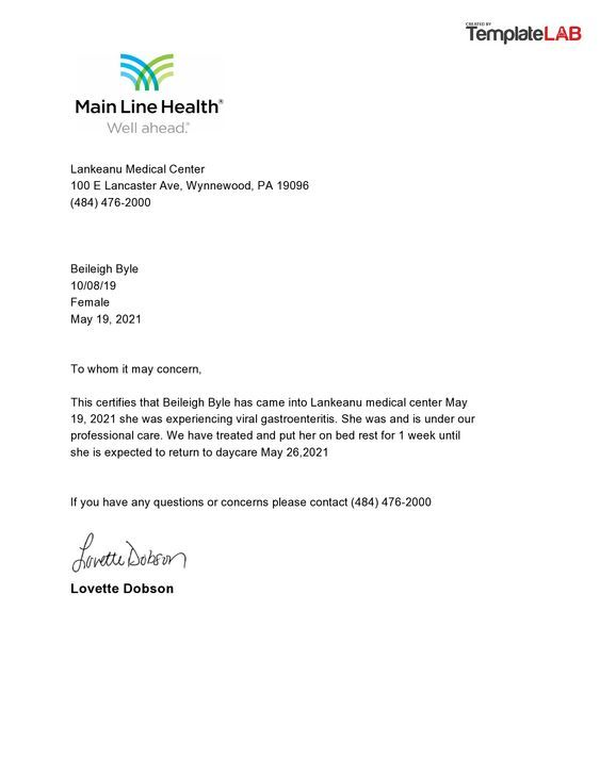

In [6]:
inspect_path  = image_paths[INSPECT_INDEX]
inspect_image = load_image(inspect_path)

print(f"[{INSPECT_INDEX}] {inspect_path.name}")
print(f"Size: {inspect_image.size}  Mode: {inspect_image.mode}")

# Preprocess and OCR
inspect_pre   = preprocess(inspect_image)
inspect_words = ocr_words(inspect_pre) or ocr_words(inspect_pre, _OCR_CONFIG_SPARSE)
inspect_words = [w for w in inspect_words if w.get("conf", 0) >= MIN_CONFIDENCE]

print(f"OCR words (confidence >={MIN_CONFIDENCE}%): {len(inspect_words)}")

# Encode
inspect_enc = encode_layout(inspect_pre, inspect_words)

if inspect_enc:
    print("\nLayoutXLM encoding tensors:")
    for key, tensor in inspect_enc.items():
        print(f"  {key:20s}: shape {tuple(tensor.shape)}")
    non_pad = (inspect_enc["input_ids"] != _get_tokenizer().pad_token_id).sum().item()
    print(f"\nNon-padding tokens (incl. CLS/SEP): {non_pad}")
    print(f"OCR words to subword tokens ratio  : {(non_pad-2)/len(inspect_words):.2f}x")

# Display image
display_width = 600
ratio = display_width / inspect_image.width
inspect_image.resize((display_width, int(inspect_image.height * ratio)), Image.Resampling.LANCZOS)

## Step 5 -- Tokenisation Analysis Table

Shows exactly what LayoutXLM does to each OCR word:

- **OCR Word** -- the raw word Tesseract returned
- **Subword Tokens** -- how SentencePiece splits it (word-start marker prefix on first piece)
- **Token IDs** -- the integer IDs looked up in LayoutXLM's 250,002-token vocabulary
- **Pixel BBox** -- the original pixel coordinates (x, y, width, height) from Tesseract
- **Normalised BBox** -- scaled to 0-1000 (what gets fed to the model)

In [7]:
import pandas as pd


def tokenization_table(image: Image.Image, words: list[dict], max_rows: int = 40) -> pd.DataFrame:
    tokenizer = _get_tokenizer()
    norm_boxes = normalize_boxes(words, image.width, image.height)
    rows = []
    for w, nb in zip(words, norm_boxes):
        subwords = tokenizer.tokenize(w["word"])
        ids      = tokenizer.convert_tokens_to_ids(subwords)
        rows.append({
            "OCR Word":       w["word"],
            "Subword Tokens": " ".join(subwords),
            "Token IDs":      ids,
            "Conf %":         round(w["conf"]),
            "Pixel BBox":     (w["x"], w["y"], w["w"], w["h"]),
            "Norm BBox":      tuple(nb),
        })
    return pd.DataFrame(rows[:max_rows])


tok_df = tokenization_table(inspect_pre, inspect_words)

pd.set_option("display.max_colwidth", 30)
pd.set_option("display.max_rows", 40)

n_splits = sum(1 for _, r in tok_df.iterrows() if " " in str(r["Subword Tokens"]))
print(f"Showing first {len(tok_df)} of {len(inspect_words)} OCR words")
print(f"Words split into multiple subwords: {n_splits} ({100*n_splits//max(len(tok_df),1)}%)")
tok_df

Showing first 40 of 92 OCR words
Words split into multiple subwords: 40 (100%)


,OCR Word,Subword Tokens,Token IDs,Conf %,Pixel BBox,Norm BBox
0,TempiateLAB,▁Temp iate LAB <pad> <pad>...,"[37446, 101426, 89549, 1, ...",86,"(874, 43, 217, 41)","(776, 29, 968, 57)"
1,Main,▁Main <pad> <pad> <pad> <p...,"[12321, 1, 1, 1, 1, 1, 1, ...",96,"(142, 187, 76, 26)","(126, 128, 193, 146)"
2,Line,▁Line <pad> <pad> <pad> <p...,"[16777, 1, 1, 1, 1, 1, 1, ...",96,"(227, 187, 68, 26)","(201, 128, 261, 146)"
3,"Health""","▁Health "" <pad> <pad> <pad...","[19102, 58, 1, 1, 1, 1, 1,...",93,"(303, 187, 115, 26)","(269, 128, 371, 146)"
4,Well,▁Well <pad> <pad> <pad> <p...,"[22576, 1, 1, 1, 1, 1, 1, ...",84,"(202, 232, 54, 17)","(179, 159, 227, 170)"
5,ahead,▁ahead <pad> <pad> <pad> <...,"[99255, 1, 1, 1, 1, 1, 1, ...",41,"(267, 232, 77, 17)","(237, 159, 305, 170)"
6,Lankeanu,▁Lan k eanu <pad> <pad> <p...,"[10082, 92, 110421, 1, 1, ...",92,"(133, 309, 95, 17)","(118, 211, 202, 223)"
7,Medical,▁Medical <pad> <pad> <pad>...,"[69292, 1, 1, 1, 1, 1, 1, ...",96,"(236, 309, 75, 17)","(209, 211, 276, 223)"
8,Center,▁Center <pad> <pad> <pad> ...,"[11588, 1, 1, 1, 1, 1, 1, ...",96,"(318, 308, 66, 18)","(282, 211, 341, 223)"
9,100,▁100 <pad> <pad> <pad> <pa...,"[805, 1, 1, 1, 1, 1, 1, 1,...",93,"(134, 340, 34, 17)","(119, 233, 149, 244)"


## Step 6 -- Spatial Layout Visualisation

Draws each OCR word's bounding box on the document image. The colour cycles through a
palette so adjacent words are visually distinct. This shows the spatial information that
LayoutXLM encodes alongside the text -- the reason it outperforms plain BERT on documents.

Bboxes drawn for 80 of 92 OCR words


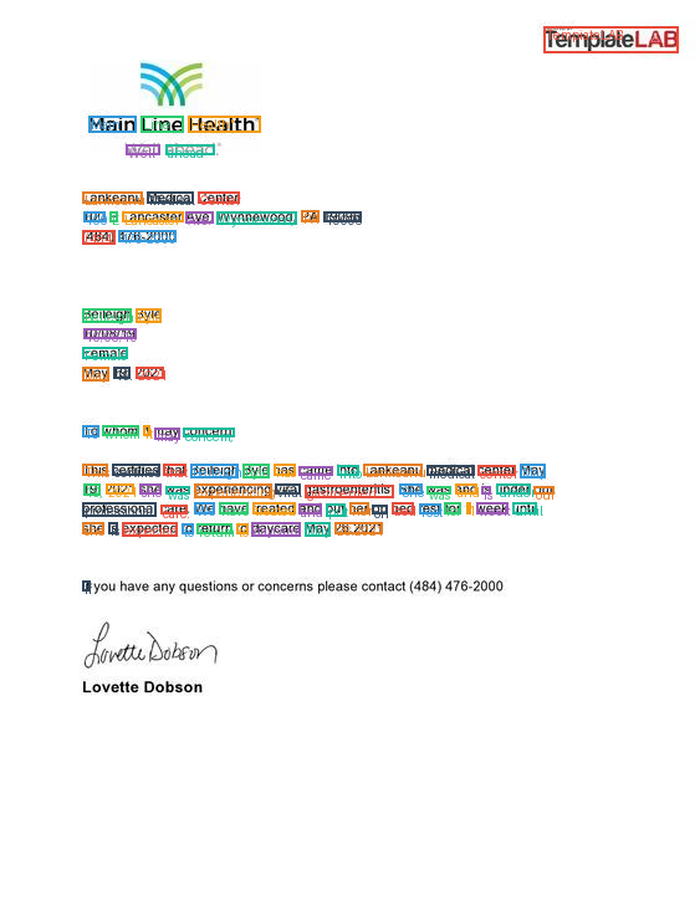

In [8]:
_PALETTE = [
    "#e74c3c", "#3498db", "#2ecc71", "#f39c12",
    "#9b59b6", "#1abc9c", "#e67e22", "#34495e",
]


def draw_ocr_layout(image: Image.Image, words: list[dict], max_words: int = 80) -> Image.Image:
    annotated = image.convert("RGB")
    draw      = ImageDraw.Draw(annotated)
    for i, w in enumerate(words[:max_words]):
        color = _PALETTE[i % len(_PALETTE)]
        # words come from preprocessed (2x upscaled) image; halve coords for display
        x0 = w["x"] // 2
        y0 = w["y"] // 2
        x1 = (w["x"] + w["w"]) // 2
        y1 = (w["y"] + w["h"]) // 2
        draw.rectangle((x0, y0, x1, y1), outline=color, width=2)
        draw.text((x0 + 2, y0 + 1), w["word"][:12], fill=color)
    return annotated


annotated = draw_ocr_layout(inspect_image, inspect_words)
print(f"Bboxes drawn for {min(80, len(inspect_words))} of {len(inspect_words)} OCR words")

display_width = 700
ratio = display_width / annotated.width
annotated.resize((display_width, int(annotated.height * ratio)), Image.Resampling.LANCZOS)

## Step 7 -- Batch Token Statistics

Runs OCR + tokenisation over every image in `IMAGE_FOLDER` and collects:

- **ocr_words** -- how many words Tesseract returned (after confidence filter)
- **layout_tokens** -- how many subword tokens LayoutXLM produces (excl. CLS/SEP/padding)
- **subword_ratio** -- tokens divided by words (> 1.0 means some words split into multiple subwords)
- **non_latin** -- words that contain non-ASCII characters (shows multilingual coverage)

In [9]:
results = []

for i, path in enumerate(image_paths):
    print(f"[{i+1}/{len(image_paths)}] {path.name} ...", end=" ", flush=True)
    try:
        img   = load_image(path)
        pre   = preprocess(img)
        words = ocr_words(pre) or ocr_words(pre, _OCR_CONFIG_SPARSE)
        words = [w for w in words if w.get("conf", 0) >= MIN_CONFIDENCE]

        enc = encode_layout(pre, words)
        if enc:
            tok   = _get_tokenizer()
            n_tok = (enc["input_ids"] != tok.pad_token_id).sum().item() - 2
        else:
            n_tok = 0

        non_latin = sum(1 for w in words if not w["word"].isascii())
        ratio     = round(n_tok / len(words), 2) if words else 0.0

        results.append({
            "file":            path.name,
            "subfolder":       path.parent.name,
            "ocr_words":       len(words),
            "layout_tokens":   n_tok,
            "subword_ratio":   ratio,
            "non_latin_words": non_latin,
        })
        print(f"OK  (words: {len(words)}, tokens: {n_tok}, ratio: {ratio}x)")
    except Exception as exc:
        print(f"FAILED -- {exc}")
        results.append({
            "file":      path.name,
            "subfolder": path.parent.name,
            "error":     str(exc),
        })

print(f"\nDone. {len(results)} image(s) processed.")

[1/23] Sick_Note_1.jpg ... OK  (words: 92, tokens: 136, ratio: 1.48x)
[2/23] Sick_note_2.jpg ... OK  (words: 105, tokens: 164, ratio: 1.56x)
[3/23] Sick_note_8.pdf ... warning: The `fitz` API is deprecated and will be removed in future. Use `import pymupdf` instead.
OK  (words: 197, tokens: 313, ratio: 1.59x)
[4/23] sick_note_10.jpg ... OK  (words: 172, tokens: 298, ratio: 1.73x)
[5/23] sick_note_12.pdf ... OK  (words: 120, tokens: 178, ratio: 1.48x)
[6/23] sick_note_13.jpg ... OK  (words: 56, tokens: 107, ratio: 1.91x)
[7/23] sick_note_14.pdf ... OK  (words: 233, tokens: 353, ratio: 1.52x)
[8/23] sick_note_15.jpg ... OK  (words: 239, tokens: 358, ratio: 1.5x)
[9/23] sick_note_17.pdf ... OK  (words: 151, tokens: 235, ratio: 1.56x)
[10/23] sick_note_18.pdf ... OK  (words: 241, tokens: 372, ratio: 1.54x)
[11/23] sick_note_19.png ... OK  (words: 136, tokens: 280, ratio: 2.06x)
[12/23] sick_note_20.pdf ... OK  (words: 206, tokens: 291, ratio: 1.41x)
[13/23] sick_note_21.pdf ... OK  (words:

### Results DataFrame and Summary

In [10]:
import pandas as pd

df = pd.DataFrame(results)
pd.set_option("display.max_colwidth", 35)

display(df)

ok_rows = [r for r in results if "error" not in r]
if ok_rows:
    avg_words  = sum(r["ocr_words"]       for r in ok_rows) / len(ok_rows)
    avg_tokens = sum(r["layout_tokens"]   for r in ok_rows) / len(ok_rows)
    avg_ratio  = sum(r["subword_ratio"]   for r in ok_rows) / len(ok_rows)
    total_nl   = sum(r["non_latin_words"] for r in ok_rows)
    print(f"\n=== Batch Summary ({len(ok_rows)} images) ===")
    print(f"Avg OCR words per image    : {avg_words:.1f}")
    print(f"Avg LayoutXLM tokens       : {avg_tokens:.1f}")
    print(f"Avg subword ratio          : {avg_ratio:.2f}x")
    print(f"Total non-Latin words      : {total_nl}  (multilingual content)")
    errors = len(results) - len(ok_rows)
    if errors:
        print(f"Errors                     : {errors}")

,file,subfolder,ocr_words,layout_tokens,subword_ratio,non_latin_words
0,Sick_Note_1.jpg,Test data,92,136,1.48,0
1,Sick_note_2.jpg,Test data,105,164,1.56,0
2,Sick_note_8.pdf,Test data,197,313,1.59,1
3,sick_note_10.jpg,Test data,172,298,1.73,1
4,sick_note_12.pdf,Test data,120,178,1.48,0
5,sick_note_13.jpg,Test data,56,107,1.91,0
6,sick_note_14.pdf,Test data,233,353,1.52,0
7,sick_note_15.jpg,Test data,239,358,1.50,2
8,sick_note_17.pdf,Test data,151,235,1.56,1
9,sick_note_18.pdf,Test data,241,372,1.54,4



=== Batch Summary (23 images) ===
Avg OCR words per image    : 145.9
Avg LayoutXLM tokens       : 239.8
Avg subword ratio          : 1.68x
Total non-Latin words      : 22  (multilingual content)


## Step 8 -- Embedding Space Visualisation (PCA)

LayoutXLM encodes each subword token as a **768-dimensional vector**. We can project these
down to 2D with PCA to see how the token vocabulary organises itself in embedding space.

**What we visualise:** the word embedding lookup layer weights -- the 768-dim vector
assigned to each token ID in LayoutXLM's 250,002-token vocabulary.  
**Why not the full contextual embeddings?** Those require `LayoutLMv2Model` with the
detectron2 visual backbone (not installed). The word embedding layer is the first stage of
the same model and gives a clear view of semantic structure.

**What the plot shows:**
- Each **point** = one OCR word from the inspected image (first subword piece used)
- **Position** = where that token sits in the learned embedding space (PCA 2D projection)
- **Colour** = line on the document the word came from (shows whether words on the same
  line cluster together in embedding space, or whether semantic meaning dominates)

The fallback uses `xlm-roberta-base` word embeddings if `LayoutLMv2Model` cannot load.
Both share the exact same SentencePiece vocabulary (250,002 tokens), so token IDs are
identical -- only the weights differ slightly.

Loading LayoutLMv2Model for embedding weights (may take ~30s) ...
LayoutLMv2Model failed (ImportError), falling back to xlm-roberta-base ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9076.01it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix loaded: (250002, 768)  source: XLM-RoBERTa base (same 250k vocab, proxy for LayoutXLM)


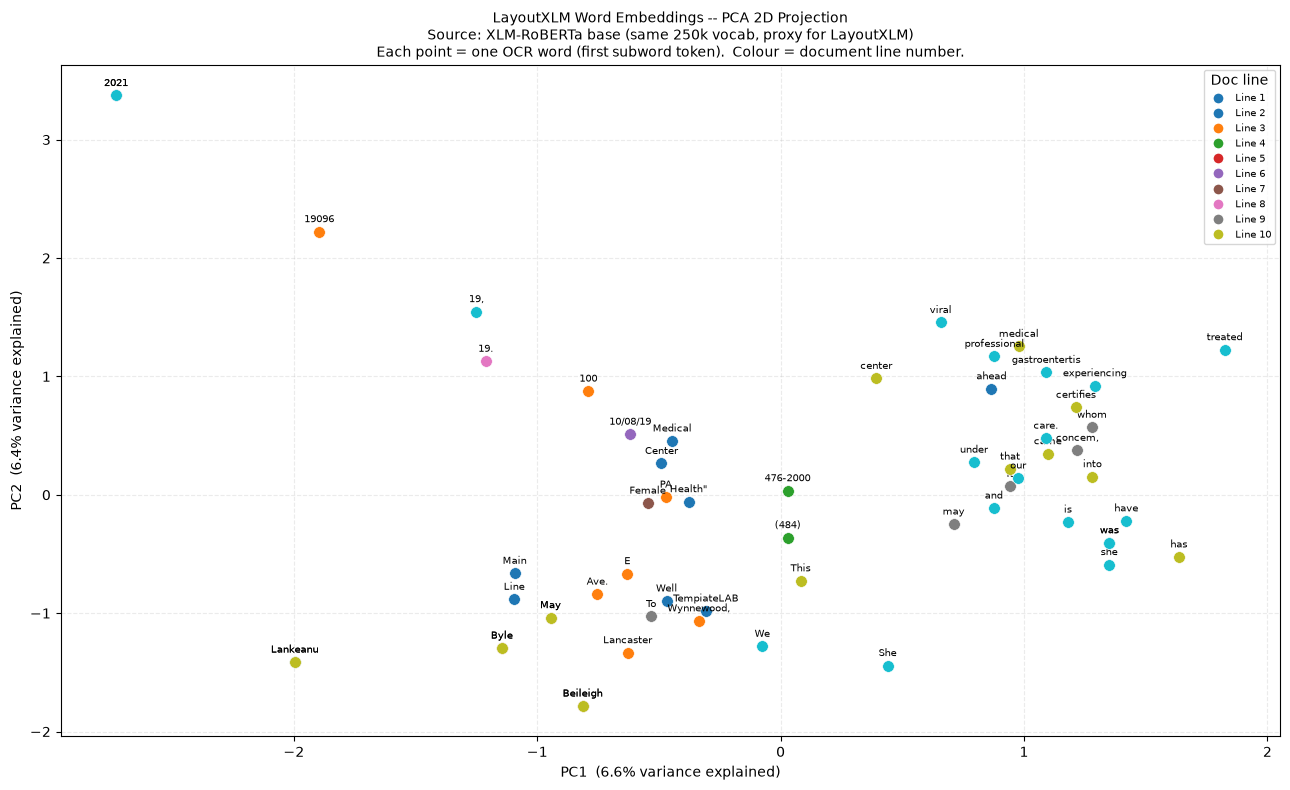


Points plotted : 60
PCA variance   : PC1=6.6%  PC2=6.4%  total=12.9%


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -- Load word embedding weights -----------------------------------------------
_embed_weights = None
_embed_source  = None

def _load_embed_weights():
    global _embed_weights, _embed_source
    if _embed_weights is not None:
        return _embed_weights, _embed_source
    try:
        from transformers import LayoutLMv2Model
        print("Loading LayoutLMv2Model for embedding weights (may take ~30s) ...")
        m = LayoutLMv2Model.from_pretrained("microsoft/layoutxlm-base")
        _embed_weights = m.layoutlmv2.embeddings.word_embeddings.weight.detach().numpy()
        _embed_source  = "LayoutXLM (microsoft/layoutxlm-base)"
        del m
    except Exception as e:
        print(f"LayoutLMv2Model failed ({type(e).__name__}), falling back to xlm-roberta-base ...")
        from transformers import XLMRobertaModel
        m = XLMRobertaModel.from_pretrained("xlm-roberta-base")
        _embed_weights = m.embeddings.word_embeddings.weight.detach().numpy()
        _embed_source  = "XLM-RoBERTa base (same 250k vocab, proxy for LayoutXLM)"
        del m
    print(f"Embedding matrix loaded: {_embed_weights.shape}  source: {_embed_source}")
    return _embed_weights, _embed_source


# -- Build per-word embedding vectors ------------------------------------------
def word_embeddings_from_ocr(words: list[dict], max_words: int = 60):
    W, src = _load_embed_weights()
    tok    = _get_tokenizer()
    vecs, labels, line_ids = [], [], []
    for w in words[:max_words]:
        ids = tok.convert_tokens_to_ids(tok.tokenize(w["word"]))
        if not ids:
            continue
        vecs.append(W[ids[0]])      # first subword piece represents the word
        labels.append(w["word"][:14])
        line_ids.append(w["line"])
    return np.array(vecs), labels, line_ids, src


vecs, labels, line_ids, src = word_embeddings_from_ocr(inspect_words)

# -- PCA 2D projection ---------------------------------------------------------
pca  = PCA(n_components=2, random_state=42)
pts  = pca.fit_transform(vecs)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# -- Plot ----------------------------------------------------------------------
unique_lines = sorted(set(line_ids))
cmap         = plt.colormaps["tab10"].resampled(max(len(unique_lines), 1))
line_color   = {ln: cmap(i) for i, ln in enumerate(unique_lines)}

fig, ax = plt.subplots(figsize=(13, 8))
for i, (x, y) in enumerate(pts):
    c = line_color[line_ids[i]]
    ax.scatter(x, y, color=c, s=70, zorder=3, edgecolors="white", linewidths=0.4)
    ax.annotate(
        labels[i], (x, y),
        fontsize=7.5, ha="center", va="bottom",
        xytext=(0, 5), textcoords="offset points",
        color="black",
    )

ax.set_title(
    f"LayoutXLM Word Embeddings -- PCA 2D Projection\n"
    f"Source: {src}\n"
    f"Each point = one OCR word (first subword token).  "
    f"Colour = document line number.",
    fontsize=10,
)
ax.set_xlabel(f"PC1  ({var1:.1f}% variance explained)")
ax.set_ylabel(f"PC2  ({var2:.1f}% variance explained)")
ax.grid(True, alpha=0.25, linestyle="--")

handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=line_color[ln], markersize=8,
               label=f"Line {ln}")
    for ln in unique_lines[:10]
]
ax.legend(handles=handles, title="Doc line", fontsize=7, loc="best")

plt.tight_layout()
plt.show()

print(f"\nPoints plotted : {len(pts)}")
print(f"PCA variance   : PC1={var1:.1f}%  PC2={var2:.1f}%  total={var1+var2:.1f}%")


## Step 9 -- Multi-File Embedding Comparison (PCA)

Projects word embeddings from **all 23 test documents** into the same 2D PCA space so you
can compare vocabulary distributions across files and categories.

**Colour** = individual file (each file gets a unique colour from the HSV wheel).  
**Marker shape** = document category (subfolder):

| Shape | Category |
|---|---|
| `o` circle | Test data |
| `*` star | authentic |
| `D` diamond | fake |
| `^` triangle | suspicious |

**What to look for:**
- Points from different files clustering in the same region = shared vocabulary (common
  medical terms, numbers, dates) — LayoutXLM has seen these across all document types
- A file's points scattered far from all others = unusual vocabulary or OCR noise
- Authentic vs fake vs suspicious overlapping = embedding space alone cannot distinguish
  document authenticity (you need layout + fine-tuning for that)

| Setting | Effect |
|---|---|
| `MAX_WORDS_PER_FILE` | Words sampled per document — lower = faster, less overlap |

Total embedding points : 460  (23 files x up to 20 words)


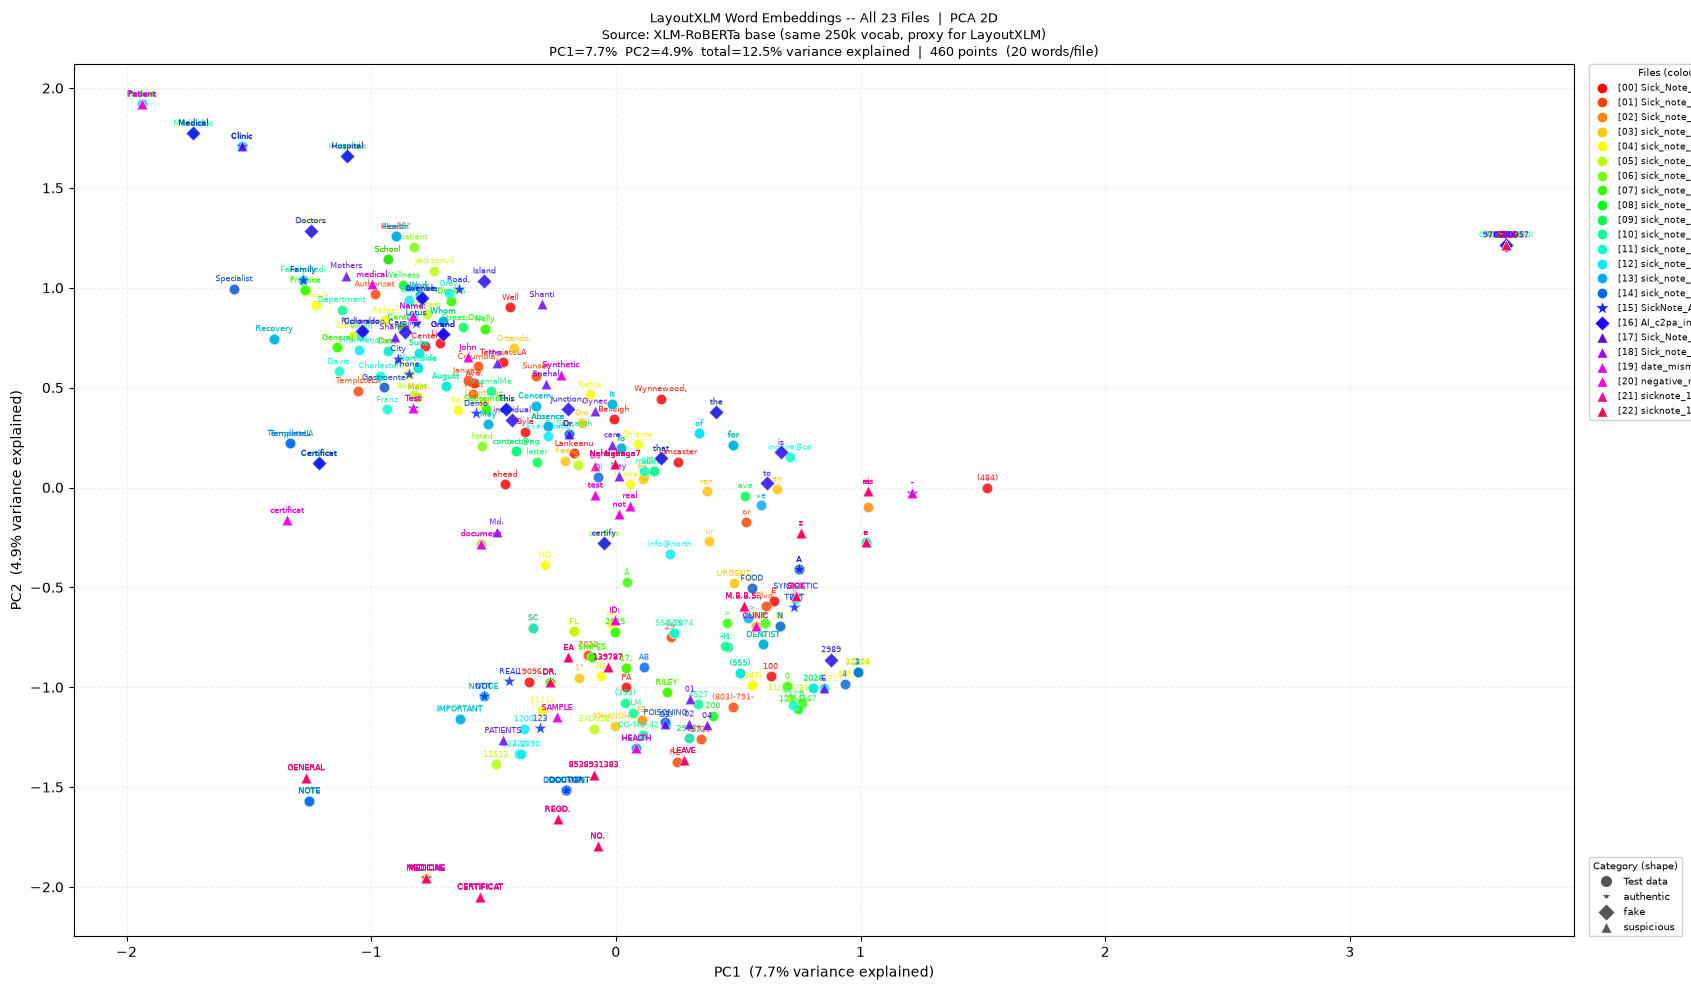


Points plotted : 460
PCA variance   : PC1=7.7%  PC2=4.9%  total=12.5%


In [12]:
MAX_WORDS_PER_FILE = 20   # words sampled per document; lower = faster, less overlap

# -- Marker shape per subfolder ------------------------------------------------
_SUBFOLDER_MARKER = {
    "Test data":  "o",
    "authentic":  "*",
    "fake":       "D",
    "suspicious": "^",
}
_DEFAULT_MARKER = "s"

# -- Collect embeddings for all files ------------------------------------------
W, embed_src = _load_embed_weights()
tok = _get_tokenizer()

all_vecs, all_labels, all_file_ids, all_file_names, all_subfolders = [], [], [], [], []

for file_idx, path in enumerate(image_paths):
    try:
        img   = load_image(path)
        pre   = preprocess(img)
        words = ocr_words(pre) or ocr_words(pre, _OCR_CONFIG_SPARSE)
        words = [w for w in words if w.get("conf", 0) >= MIN_CONFIDENCE]
        for w in words[:MAX_WORDS_PER_FILE]:
            ids = tok.convert_tokens_to_ids(tok.tokenize(w["word"]))
            if not ids:
                continue
            all_vecs.append(W[ids[0]])
            all_labels.append(w["word"][:10])
            all_file_ids.append(file_idx)
            all_file_names.append(path.stem[:22])
            all_subfolders.append(path.parent.name)
    except Exception as exc:
        print(f"Skipped {path.name}: {exc}")

all_vecs = np.array(all_vecs)
n_files  = len(image_paths)
print(f"Total embedding points : {len(all_vecs)}  ({n_files} files x up to {MAX_WORDS_PER_FILE} words)")

# -- PCA -----------------------------------------------------------------------
pca  = PCA(n_components=2, random_state=42)
pts  = pca.fit_transform(all_vecs)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# -- Colour: one unique colour per file ----------------------------------------
file_cmap  = plt.colormaps["hsv"].resampled(n_files + 1)
file_color = [file_cmap(i / (n_files + 1)) for i in range(n_files)]

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(17, 10))

for i, (x, y) in enumerate(pts):
    fid    = all_file_ids[i]
    marker = _SUBFOLDER_MARKER.get(all_subfolders[i], _DEFAULT_MARKER)
    msize  = 90 if marker == "*" else 55
    ax.scatter(x, y,
               color=file_color[fid], marker=marker,
               s=msize, alpha=0.82, zorder=3,
               edgecolors="white", linewidths=0.3)
    ax.annotate(
        all_labels[i], (x, y),
        fontsize=5.5, ha="center", va="bottom",
        xytext=(0, 4), textcoords="offset points",
        color=file_color[fid], alpha=0.9,
    )

# -- Legend 1: file colours (outside right) ------------------------------------
file_legend_handles = []
seen = {}
for fid, name in zip(all_file_ids, all_file_names):
    if fid not in seen:
        seen[fid] = name
for fid in sorted(seen):
    sf  = all_subfolders[all_file_ids.index(fid)]
    mkr = _SUBFOLDER_MARKER.get(sf, _DEFAULT_MARKER)
    mz  = 12 if mkr == "*" else 8
    file_legend_handles.append(
        plt.Line2D([0], [0], marker=mkr, color="w",
                   markerfacecolor=file_color[fid], markersize=mz,
                   label=f"[{fid:02d}] {seen[fid]}")
    )

leg1 = ax.legend(
    handles=file_legend_handles,
    title="Files (colour)",
    fontsize=6.5, title_fontsize=7,
    loc="upper left", bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0, framealpha=0.9,
)
ax.add_artist(leg1)

# -- Legend 2: category shapes (bottom right) ----------------------------------
cat_handles = [
    plt.Line2D([0], [0], marker=mk, color="w",
               markerfacecolor="#555", markersize=9,
               label=cat)
    for cat, mk in _SUBFOLDER_MARKER.items()
]
ax.legend(
    handles=cat_handles,
    title="Category (shape)",
    fontsize=7, title_fontsize=7.5,
    loc="lower left", bbox_to_anchor=(1.01, 0.0),
    borderaxespad=0, framealpha=0.9,
)

ax.set_title(
    f"LayoutXLM Word Embeddings -- All {n_files} Files  |  PCA 2D\n"
    f"Source: {embed_src}\n"
    f"PC1={var1:.1f}%  PC2={var2:.1f}%  total={var1+var2:.1f}% variance explained  "
    f"|  {len(pts)} points  ({MAX_WORDS_PER_FILE} words/file)",
    fontsize=9.5,
)
ax.set_xlabel(f"PC1  ({var1:.1f}% variance explained)")
ax.set_ylabel(f"PC2  ({var2:.1f}% variance explained)")
ax.grid(True, alpha=0.18, linestyle="--")

plt.tight_layout()
plt.show()

print(f"\nPoints plotted : {len(pts)}")
print(f"PCA variance   : PC1={var1:.1f}%  PC2={var2:.1f}%  total={var1+var2:.1f}%")


## Step 10 -- 3D Embedding Comparison (PCA 3 Components)

Same data as Step 9 but projected into **three principal components** instead of two.
The extra dimension often separates clusters that overlap in 2D.

- **Colour** = individual file (same HSV palette as Step 9)
- **Marker shape** = document category (same mapping)
- **Axes** = PC1, PC2, PC3 -- the three directions of greatest variance in embedding space
- Set `SHOW_LABELS_3D = True` to annotate each point with its word text (slower)

In [14]:
import plotly.graph_objects as go
import matplotlib.colors as mcolors

SHOW_LABELS_3D = False   # True = annotate each point with its word text

_SUBFOLDER_SYMBOL_3D = {
    "Test data":  "circle",
    "authentic":  "square",
    "fake":       "diamond",
    "suspicious": "cross",
}

# -- PCA 3 components (reuses all_vecs from Step 9) ---------------------------
pca3 = PCA(n_components=3, random_state=42)
pts3 = pca3.fit_transform(all_vecs)
v1   = pca3.explained_variance_ratio_[0] * 100
v2   = pca3.explained_variance_ratio_[1] * 100
v3   = pca3.explained_variance_ratio_[2] * 100
print(f"PCA 3D variance: PC1={v1:.1f}%  PC2={v2:.1f}%  PC3={v3:.1f}%  total={v1+v2+v3:.1f}%")

# Convert matplotlib HSV colours to hex
hex_colors = [mcolors.to_hex(file_color[fid]) for fid in range(n_files)]

# -- One trace per file so each gets its own legend entry ---------------------
traces = []
seen_groups = set()

for fid in range(n_files):
    mask = [i for i, f in enumerate(all_file_ids) if f == fid]
    if not mask:
        continue

    sf     = all_subfolders[mask[0]]
    symbol = _SUBFOLDER_SYMBOL_3D.get(sf, "circle")
    fname  = all_file_names[mask[0]]
    labels = [all_labels[i] for i in mask]

    # show category group title only on its first file
    grp_title = sf if sf not in seen_groups else ""
    seen_groups.add(sf)

    traces.append(go.Scatter3d(
        x=pts3[mask, 0],
        y=pts3[mask, 1],
        z=pts3[mask, 2],
        mode="markers+text" if SHOW_LABELS_3D else "markers",
        text=labels,
        textposition="top center",
        textfont=dict(size=7),
        marker=dict(
            size=5,
            symbol=symbol,
            color=hex_colors[fid],
            opacity=0.88,
            line=dict(color="white", width=0.5),
        ),
        name=f"[{fid:02d}] {fname}",
        legendgroup=sf,
        legendgrouptitle_text=grp_title,
        hovertemplate=(
            "<b>%{text}</b><br>"
            f"File: {fname}<br>"
            f"Category: {sf}<br>"
            "PC1=%{x:.3f}<br>PC2=%{y:.3f}<br>PC3=%{z:.3f}"
            "<extra></extra>"
        ),
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    title=dict(
        text=(
            f"LayoutXLM Word Embeddings -- All {n_files} Files  |  Interactive PCA 3D<br>"
            f"<sup>PC1={v1:.1f}%  PC2={v2:.1f}%  PC3={v3:.1f}%  "
            f"total={v1+v2+v3:.1f}% variance  |  "
            f"{len(pts3)} points  ({MAX_WORDS_PER_FILE} words/file)</sup>"
        ),
        font_size=13,
    ),
    scene=dict(
        xaxis_title=f"PC1  ({v1:.1f}%)",
        yaxis_title=f"PC2  ({v2:.1f}%)",
        zaxis_title=f"PC3  ({v3:.1f}%)",
        bgcolor="rgba(245,245,250,1)",
        xaxis=dict(gridcolor="white", backgroundcolor="rgba(230,230,240,0.6)"),
        yaxis=dict(gridcolor="white", backgroundcolor="rgba(230,240,230,0.6)"),
        zaxis=dict(gridcolor="white", backgroundcolor="rgba(240,230,230,0.6)"),
    ),
    legend=dict(
        title="Files & Categories",
        font_size=9,
        groupclick="toggleitem",
        tracegroupgap=4,
    ),
    margin=dict(l=0, r=180, t=80, b=0),
    width=1100,
    height=700,
)

fig.show()


PCA 3D variance: PC1=7.7%  PC2=4.9%  PC3=3.7%  total=16.3%
